<a href="https://colab.research.google.com/github/Zuhair0000/tensorflow_bootcamp/blob/main/07_milestone_project_1_food_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-d366727e-b500-d247-f91e-f6ed178ec066)


In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-02-22 05:01:18--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-02-22 05:01:19 (98.3 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

# Tensorflow datasets

In [4]:
import tensorflow_datasets as tfds

In [5]:
datasets_list = tfds.list_builders()
print("food101" in datasets_list)

True


In [6]:
(train_data, test_data), ds_info = tfds.load(name='food101',
                                             split=['train', 'validation'],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.1GY7KE_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.1GY7KE_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [7]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [8]:
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [9]:
ds_info.features['image'].shape

(None, None, 3)

In [10]:
train_one_sample = train_data.take(1)

In [11]:
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [12]:
for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image datatype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[label.numpy()]}
  """)


  Image shape: (512, 512, 3)
  Image datatype: <dtype: 'uint8'>
  Target class from Food101 (tensor form): 21
  Class name (str form): chocolate_cake
  


In [13]:
import tensorflow as tf

tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

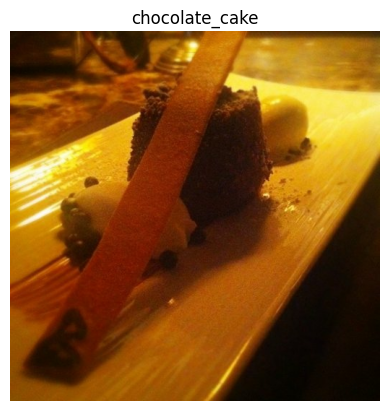

In [14]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

# Create preprocessing functions

In [16]:
def preprocess_img(image, label, img_shape=224):
  image = tf.image.resize(image, [img_shape, img_shape])
  return tf.cast(image, tf.float32), label

In [17]:
preprocessed_image = preprocess_img(image, label)[0]

In [18]:
preprocessed_image

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[2.9198980e+01, 1.1198979e+01, 0.0000000e+00],
        [2.8285715e+01, 1.2285714e+01, 0.0000000e+00],
        [3.0852041e+01, 1.5494898e+01, 2.8061217e-01],
        ...,
        [5.2933601e+01, 3.2505074e+01, 8.7193365e+00],
        [5.4025528e+01, 3.4025528e+01, 1.0025528e+01],
        [5.3800972e+01, 3.3800972e+01, 9.5713587e+00]],

       [[3.3096939e+01, 1.5096939e+01, 1.1938781e+00],
        [3.3785713e+01, 1.7785715e+01, 2.7857151e+00],
        [3.1785713e+01, 1.6428572e+01, 1.2142859e+00],
        ...,
        [6.3602058e+01, 4.2530632e+01, 1.5346998e+01],
        [6.1647934e+01, 4.0785702e+01, 1.3928558e+01],
        [6.0785713e+01, 4.1714287e+01, 1.2020403e+01]],

       [[3.1576530e+01, 1.3576531e+01, 6.4285755e-01],
        [3.3357147e+01, 1.7357143e+01, 2.3571434e+00],
        [3.6168365e+01, 2.0811226e+01, 5.5969391e+00],
        ...,
        [6.7688797e+01, 4.4474506e+01, 1.0852092e+01],
        [6.9959167e+01